In [3]:
try:
    %load_ext autotime
except:
    %pip3 install ipython-autotime
    %load_ext autotime

time: 0 ns (started: 2024-11-13 19:06:02 -08:00)


<h2>Exact Approaches for Solving TSPs</h2>

We will go over some exact approaches including the <u> famous Held-Karp algorithm</u>, followed by some approaches based on integer linear programs.

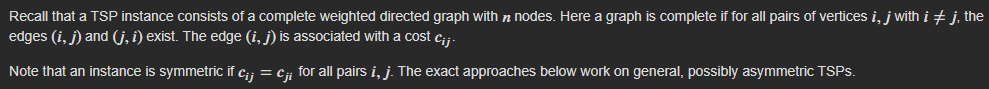


A <u> simple brute force </u> approach works as follows:

- Go through all possible permutations of the numbers  1,…,𝑛 : there are  𝑛!  such permutations.
- Each permutation denotes a possible TSP tour. Compute its cost by summing up all the edge weights.
- Retain the permutation with the minimum cost.

The algorithm is simple, but its running time is  𝑂(𝑛×𝑛!). This is because we go through  𝑛!
  permutations in total with each permutation requiring  𝑂(𝑛) time to compute its cost.

Exact Approaches for Solving TSPs
We will go over some exact approaches including the famous Held-Karp algorithm, followed by some approaches based on integer linear programs.

Recall that a TSP instance consists of a complete weighted directed graph with  𝑛
  nodes. Here a graph is complete if for all pairs of vertices  𝑖,𝑗
  with  𝑖≠𝑗
 , the edges  (𝑖,𝑗)
  and  (𝑗,𝑖)
  exist. The edge  (𝑖,𝑗)
  is associated with a cost  𝑐𝑖𝑗
 .

Note that an instance is symmetric if  𝑐𝑖𝑗=𝑐𝑗𝑖
  for all pairs  𝑖,𝑗
 . The exact approaches below work on general, possibly asymmetric TSPs.

A simple brute force approach works as follows:

Go through all possible permutations of the numbers  1,…,𝑛
 : there are  𝑛!
  such permutations.
Each permutation denotes a possible TSP tour. Compute its cost by summing up all the edge weights.
Retain the permutation with the minimum cost.
The algorithm is simple, but its running time is  𝑂(𝑛×𝑛!)
 . This is because we go through  𝑛!
  permutations in total with each permutation requiring  𝑂(𝑛)
  time to compute its cost.

Can we do better than the brute force approach above? Indeed: we will now look at a dynamic programming algorithm by Held and Karp which solves the problem in time  

for an instance with  𝑛  nodes.




<h2>Held and Karp's Algorithm</h2>

This algorithm was proposed by Bellman (who pioneered dynamic programming) and Held and Karp in 1962.

The key idea is to think of constructing a TSP tour in terms of <u>combinations</u> (order of visit of vertices does not matter) where we try to delay specifying the precise order in which nodes are visited, as much as possible) rather than <u>permutations</u>. To do so, it is convenient to think about paths rather than cycles.

The key idea is to express a TSP tour in terms of finding paths through a set of nodes ending at a designated vertex. Once we do that, we develop a dynamic programming algorithm.

<h3>Basic Idea Behind Held-Karp Algorithm</h3>

The first step is to think about a TSP tour as follows:

We arbitrarily designate vertex  1 as the "start" and "end" points of the tour. A different node can be chosen instead of  1 but it does not matter to the overall operation of the algorithm.
Next, we think of the TSP tour as starting from vertex  1, and a path that visits the vertices in the set  {2,…,𝑛−1} precisely once and returning back to vertex  1.

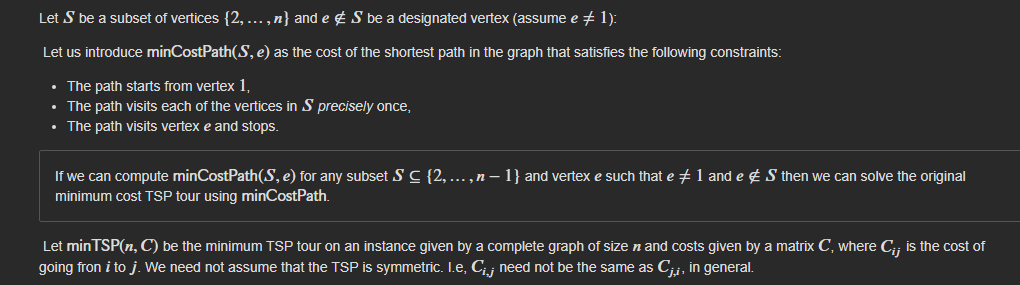
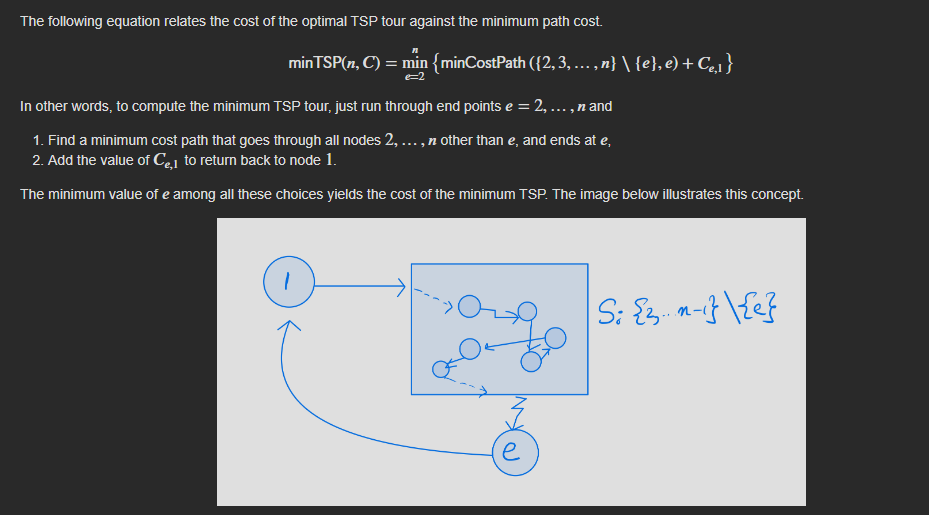




<h2>Dynamic Programming for  𝗆𝗂𝗇𝖢𝗈𝗌𝗍𝖯𝖺𝗍𝗁</h2>

We will now think about how to dynamic program for  𝗆𝗂𝗇𝖢𝗈𝗌𝗍𝖯𝖺𝗍𝗁(𝑆,𝑒) for a given set of vertices  𝑆 and  𝑒∉𝑆. We approach it in four parts:

1. Stage the decisions we need to make and identify the optimal sub-structure.
2. Create a recurrence.
3. Memoize and compute value function.
4. Recover the solution.

<h3>Staging Decisions + Optimal Substructure</h3>

The key decision that we need to make for  𝗆𝗂𝗇𝖢𝗈𝗌𝗍𝖯𝖺𝗍𝗁(𝑆,𝑒) is "which order to visit the nodes in  𝑆". We can stage this in multiple ways but the simplest one is to decide the last but one vertex in the path (or the vertex that comes immediately before the end point  𝑒). This vertex has to be part of the set  𝑆.

Once we fix a vertex  𝑠∈𝑆 as the one that occurs immediately before  𝑒, we have to find the best path that goes through  𝑆∖{𝑠} [which is subset of vertices 𝑆 from which {𝑠} is remvoed] and ends up in the node  𝑠. We can then traverse the edge  (𝑠,𝑒) to complete the original task of ending up in  𝑒.

<u> Optimal substructure</u> tells us that to find  𝗆𝗂𝗇𝖢𝗈𝗌𝗍𝖯𝖺𝗍𝗁(𝑆,𝑒), we commit to a last-but-one node  𝑠∈𝑆. What is left over is in turn to find  𝗆𝗂𝗇𝖢𝗈𝗌𝗍𝖯𝖺𝗍𝗁(𝑆,𝑠). I.e, the optimal solution to the former problem contains within it an optimal solution to the latter problem.

<h3>Recurrence</h3>

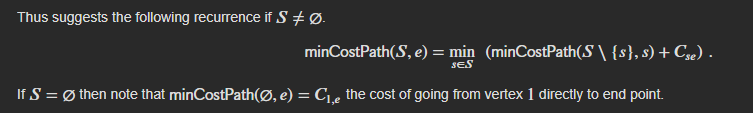

<h3>Memoization</h3>

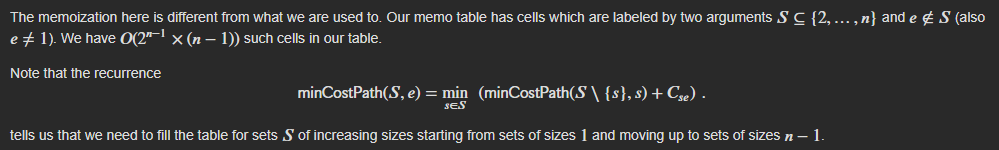

<h3>Recovering the Solution</h3>

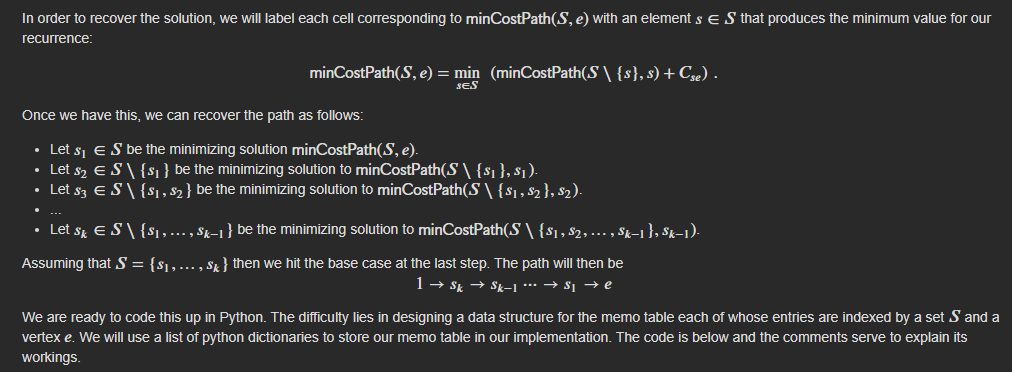

In [4]:
def memoize_min_cost_path(n, cost_matrix, debug=False):
    ## Maintaining a memo table and iterating through all sets of size $k$ systematically is  very tricky.
    ## We will just use inbuilt python data structures for this task.
    tbl = [] # Our table is simply a list of dictionaries. Each dictionary in our list is a memo table for sets of a fixed size $j$
    sol_tbl = [] # corresponding to tbl, we will hold the minimizing entry in sol_tbl to be able to recover the solution
    # tbl[i] is a dictionary that will hold all sets $S$ of size $i$ and end points e.
    # Also note that while we presented our algorithm to start from index 1, we will 
    # start our code from index 0. Therefore, vertex 0 is the starting point.
    assert len(cost_matrix) == n, f'Cost matrix is not {n}x{n}'
    assert all(len(cj) == n for cj in cost_matrix), f'Cost matrix is not {n}x{n}'
    # start by seeding the dictionary with S = emptyset
    mcp0 = {}
    sol0 = {}
    for e in range(1, n):
        S = frozenset() # frozenset in Python is an immutable set that can be hashed
        mcp0[(S, e)] = cost_matrix[0][e] # this is the base case when S = \emptyset as explained in notes above.
        sol0[(S, e)] = 0 # the previous vertex is just the start vertex 0
    tbl.append(mcp0) # add the "cost-to-go" dictionary to table
    sol_tbl.append(sol0) # add the solution dictionary to the solution table.
    ## now build up for set sizes from 1 to n-1. Set size 0 is already built and added to list at start.
    for size in range(1, n-1):
        mcp_prev = tbl[-1] # fetch the table for sets of size $n-1$.
        mcp = {} # initialize the current table
        sol = {} # initialize the current solution table
        # run through all sets of cardinality size-1
        for ((S, s), v) in mcp_prev.items():  
            assert len(S) == size-1, 'invariant failed -- the algorithm has been implemented wrong if this assertion fails'
            S_new = S.union(frozenset({s})) # make S_new = S Union {s}
            for e in range(1, n): # run through all possible end points 
                if e in S_new: # skip all end points already in the set S_new
                    continue
                new_path_cost = v + cost_matrix[s][e] # compute path cost using recursion
                old_path_cost = mcp.get((S_new, e)) # if the entry has already been added to the dictionary look it up
                old_sol = sol.get((S_new, e))
                if old_path_cost == None or old_path_cost > new_path_cost:  # if entry is not already in dictionary or tthe current solution is better than previous, replace
                    mcp[(S_new, e)] = new_path_cost
                    sol[(S_new, e)] = s
        tbl.append(mcp) # mcp is the memo table for sets of cardinality equal to the loop index size
        sol_tbl.append(sol) # sol_tbl is to be appended as well.
        if debug: # print stuff for our debugging
            print(f'Sets of size {size}')
            for ((S,e), v) in mcp.items():
                print(f'\t {S}, {e} --> {v}')
    ## Now compute best TSP tour and recover solution.
    mcp = tbl[-1] # pick up last entry 
    sol = sol_tbl[-1] 
    
    min_cost_tour = float('inf')
    end_pt = None
    # Now find the best TSP tour by using the equation that relates minCostPath to minTSPTour
    for e in range(1, n): # run through all end points
        S = frozenset({i for i in range(1, n) if i != e}) # create set S of all vertices other than e
        assert (S,e) in sol  
        v = mcp[(S,e)] # look up minCostPath(S,e)
        if v + cost_matrix[e][0] < min_cost_tour: # add the cost of retutrning from end point e to 0 to v
            min_cost_tour =  v + cost_matrix[e][0] # is it better than previous solution, if so replace.
            end_pt = e
    if debug:
        print(f'Minimum cost TSP tour: {min_cost_tour}')
        print(f'Last vertex visited before cycling back: {e}')
    # end_pt is the last vertex before cycling back to vertex 0.
    # Let's recover the tour now in the reverse order
    tour = [end_pt]
    S = frozenset({j for j in range(1, n) if j != end_pt}) # this is the set of nodes to visit
    for i in range(n-2, 0, -1):
        assert len(S) == i, f'{len(S)}, {i}'
        sol = sol_tbl[i]
        e = tour[-1]
        assert (S, e) in sol, f'Entry {(S,e)} missing from solution table: {sol}'
        new_end_pt = sol[(S,e)]
        if debug:
            print(f'Recovering solution: looking up sol[{(S, e)}] -> new end point: {new_end_pt}')
        assert new_end_pt in S
        tour.append(new_end_pt) # add new end point to the tour but remember to reverse the whole list at the end or else tour will be in reverse order 
        S = frozenset({j for j in S if j != new_end_pt}) # remove new_end_pt from the set S
        assert len(S) == i-1, f'{len(S)}, {i-1}'
    tour.append(0)
    tour.reverse() # reverse the tour since we have been appending to the end
    if debug:
        print(f'Tour:{tour}, cost: {min_cost_tour}')
    return tour, min_cost_tour
    

time: 16 ms (started: 2024-11-13 19:06:02 -08:00)


In [5]:
cost_matrix = [ [ 0, 1, 3, 4],
                [ 1, 0, 2, 3 ], 
                [ 3, 2, 0, 4 ], 
                [ 4, 3, 4, 0]]

memoize_min_cost_path(4, cost_matrix, True)

Sets of size 1
	 frozenset({1}), 2 --> 3
	 frozenset({1}), 3 --> 4
	 frozenset({2}), 1 --> 5
	 frozenset({2}), 3 --> 7
	 frozenset({3}), 1 --> 7
	 frozenset({3}), 2 --> 8
Sets of size 2
	 frozenset({1, 2}), 3 --> 7
	 frozenset({1, 3}), 2 --> 8
	 frozenset({2, 3}), 1 --> 10
Minimum cost TSP tour: 11
Last vertex visited before cycling back: 3
Recovering solution: looking up sol[(frozenset({2, 3}), 1)] -> new end point: 3
Recovering solution: looking up sol[(frozenset({2}), 3)] -> new end point: 2
Tour:[0, 2, 3, 1], cost: 11


([0, 2, 3, 1], 11)

time: 0 ns (started: 2024-11-13 19:06:02 -08:00)


In [6]:
cost_matrix = [ [ 0, 1, 3, 4, 2 ],
                [ 1, 0, 2, 3, 1 ], 
                [ 3, 2, 0, 4 , 3], 
                [ 4, 3, 4, 0, 4 ],
                [ 2, 1, 3, 4, 0 ]]

memoize_min_cost_path(5, cost_matrix, True)

Sets of size 1
	 frozenset({1}), 2 --> 3
	 frozenset({1}), 3 --> 4
	 frozenset({1}), 4 --> 2
	 frozenset({2}), 1 --> 5
	 frozenset({2}), 3 --> 7
	 frozenset({2}), 4 --> 6
	 frozenset({3}), 1 --> 7
	 frozenset({3}), 2 --> 8
	 frozenset({3}), 4 --> 8
	 frozenset({4}), 1 --> 3
	 frozenset({4}), 2 --> 5
	 frozenset({4}), 3 --> 6
Sets of size 2
	 frozenset({1, 2}), 3 --> 7
	 frozenset({1, 2}), 4 --> 6
	 frozenset({1, 3}), 2 --> 8
	 frozenset({1, 3}), 4 --> 8
	 frozenset({1, 4}), 2 --> 5
	 frozenset({1, 4}), 3 --> 6
	 frozenset({2, 3}), 1 --> 10
	 frozenset({2, 3}), 4 --> 11
	 frozenset({2, 4}), 1 --> 7
	 frozenset({2, 4}), 3 --> 9
	 frozenset({3, 4}), 1 --> 9
	 frozenset({3, 4}), 2 --> 10
Sets of size 3
	 frozenset({1, 2, 3}), 4 --> 11
	 frozenset({1, 2, 4}), 3 --> 9
	 frozenset({1, 3, 4}), 2 --> 10
	 frozenset({2, 3, 4}), 1 --> 12
Minimum cost TSP tour: 13
Last vertex visited before cycling back: 4
Recovering solution: looking up sol[(frozenset({2, 3, 4}), 1)] -> new end point: 4
Recoverin

([0, 2, 3, 4, 1], 13)

time: 0 ns (started: 2024-11-13 19:06:02 -08:00)


In [7]:
cost_matrix = [
    [ 0, 12, 10, 19, 8],
    [ 12, 0, 3, 7, 19],
    [ 10, 3, 0, 6, 20],
    [ 19, 7, 6, 0, 4],
    [ 8, 19, 20, 4, 0]
]
memoize_min_cost_path(5, cost_matrix, True)

Sets of size 1
	 frozenset({1}), 2 --> 15
	 frozenset({1}), 3 --> 19
	 frozenset({1}), 4 --> 31
	 frozenset({2}), 1 --> 13
	 frozenset({2}), 3 --> 16
	 frozenset({2}), 4 --> 30
	 frozenset({3}), 1 --> 26
	 frozenset({3}), 2 --> 25
	 frozenset({3}), 4 --> 23
	 frozenset({4}), 1 --> 27
	 frozenset({4}), 2 --> 28
	 frozenset({4}), 3 --> 12
Sets of size 2
	 frozenset({1, 2}), 3 --> 20
	 frozenset({1, 2}), 4 --> 32
	 frozenset({1, 3}), 2 --> 25
	 frozenset({1, 3}), 4 --> 23
	 frozenset({1, 4}), 2 --> 30
	 frozenset({1, 4}), 3 --> 34
	 frozenset({2, 3}), 1 --> 23
	 frozenset({2, 3}), 4 --> 20
	 frozenset({2, 4}), 1 --> 31
	 frozenset({2, 4}), 3 --> 34
	 frozenset({3, 4}), 1 --> 19
	 frozenset({3, 4}), 2 --> 18
Sets of size 3
	 frozenset({1, 2, 3}), 4 --> 24
	 frozenset({1, 2, 4}), 3 --> 36
	 frozenset({1, 3, 4}), 2 --> 22
	 frozenset({2, 3, 4}), 1 --> 21
Minimum cost TSP tour: 32
Last vertex visited before cycling back: 4
Recovering solution: looking up sol[(frozenset({1, 3, 4}), 2)] -> new 

([0, 4, 3, 1, 2], 32)

time: 15 ms (started: 2024-11-13 19:06:02 -08:00)


In [8]:
cost_matrix = [
    [0, 12, 29, 22, 13, 24],
    [12, 0, 19, 3, 25, 6],
    [29, 19, 0, 21, 23, 28],
    [22, 3, 21, 0, 4, 5],
    [13, 25, 23, 4, 0, 16],
    [24, 6, 28, 5, 16, 0]
]
memoize_min_cost_path(6, cost_matrix, True)

Sets of size 1
	 frozenset({1}), 2 --> 31
	 frozenset({1}), 3 --> 15
	 frozenset({1}), 4 --> 37
	 frozenset({1}), 5 --> 18
	 frozenset({2}), 1 --> 48
	 frozenset({2}), 3 --> 50
	 frozenset({2}), 4 --> 52
	 frozenset({2}), 5 --> 57
	 frozenset({3}), 1 --> 25
	 frozenset({3}), 2 --> 43
	 frozenset({3}), 4 --> 26
	 frozenset({3}), 5 --> 27
	 frozenset({4}), 1 --> 38
	 frozenset({4}), 2 --> 36
	 frozenset({4}), 3 --> 17
	 frozenset({4}), 5 --> 29
	 frozenset({5}), 1 --> 30
	 frozenset({5}), 2 --> 52
	 frozenset({5}), 3 --> 29
	 frozenset({5}), 4 --> 40
Sets of size 2
	 frozenset({1, 2}), 3 --> 51
	 frozenset({1, 2}), 4 --> 54
	 frozenset({1, 2}), 5 --> 54
	 frozenset({1, 3}), 2 --> 36
	 frozenset({1, 3}), 4 --> 19
	 frozenset({1, 3}), 5 --> 20
	 frozenset({1, 4}), 2 --> 57
	 frozenset({1, 4}), 3 --> 41
	 frozenset({1, 4}), 5 --> 44
	 frozenset({1, 5}), 2 --> 46
	 frozenset({1, 5}), 3 --> 23
	 frozenset({1, 5}), 4 --> 34
	 frozenset({2, 3}), 1 --> 53
	 frozenset({2, 3}), 4 --> 54
	 frozense

([0, 4, 3, 5, 1, 2], 76)

time: 0 ns (started: 2024-11-13 19:06:03 -08:00)


<h2>Integer Linear Programming Solution</h2>

We will now present two ways to formulate an ILP for the travelling salesperson problem. Once again, let  𝐶
be the cost matrix for the TSP tour, where in  𝐶𝑖,𝑗 is the cost of going from vertex  𝑖 to vertex  𝑗. Once again, we assume arbitrary TSP instance here.

We will formulate an integer linear programming problem for our TSP. We will use the following decision variables:

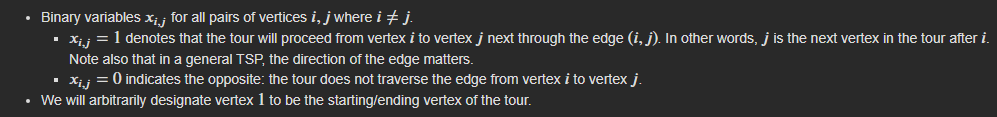

<h3>Objective Function</h3>

The objective function for the TSP will be

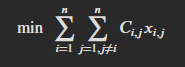


<h3>Formulating Constraints</h3>
Now we have the challenging task of formulating constraints over the decision variables  𝑥𝑖,𝑗
such that the only feasible solutions are precisely those that describe TSP tours. These constraints, combined with the objective function above, we will help us find the minimum cost TSP tour using an ILP solver.

<h3>Degree-Based Encoding</h3>

The simple idea is to constrain a tour as follows:
- For every vertex, we need to enter the vertex precisely once in our tour.
- For every vertex, we need to leave the vertex precisely once in our tour.

Clearly, any TSP tour satisfies the above constraints. And they can be encoded as follows:

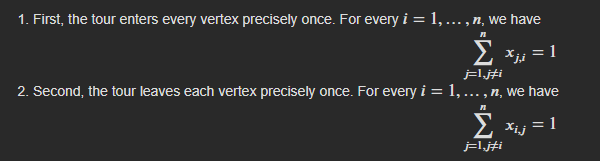

The main problem is that the two constraints above do not by themselves suffice to express the requirements of a TSP tour. I.e, all TSP tours must satisfy the constraints but there are invalid tours that satisfies the constraints, as well. The issue is that the constraints above permit "subtours". The figure below shows a subtour that will satisfy the constraints above.

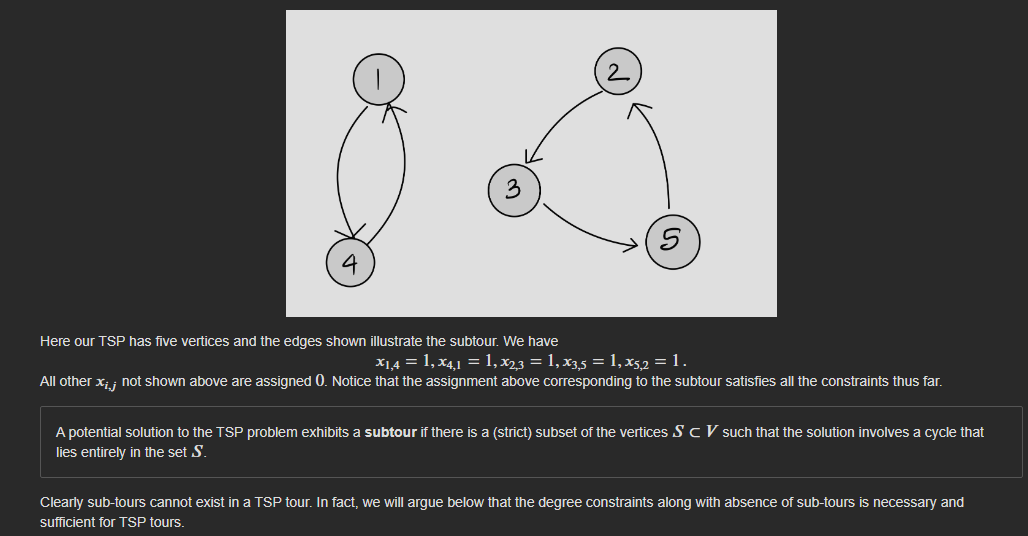




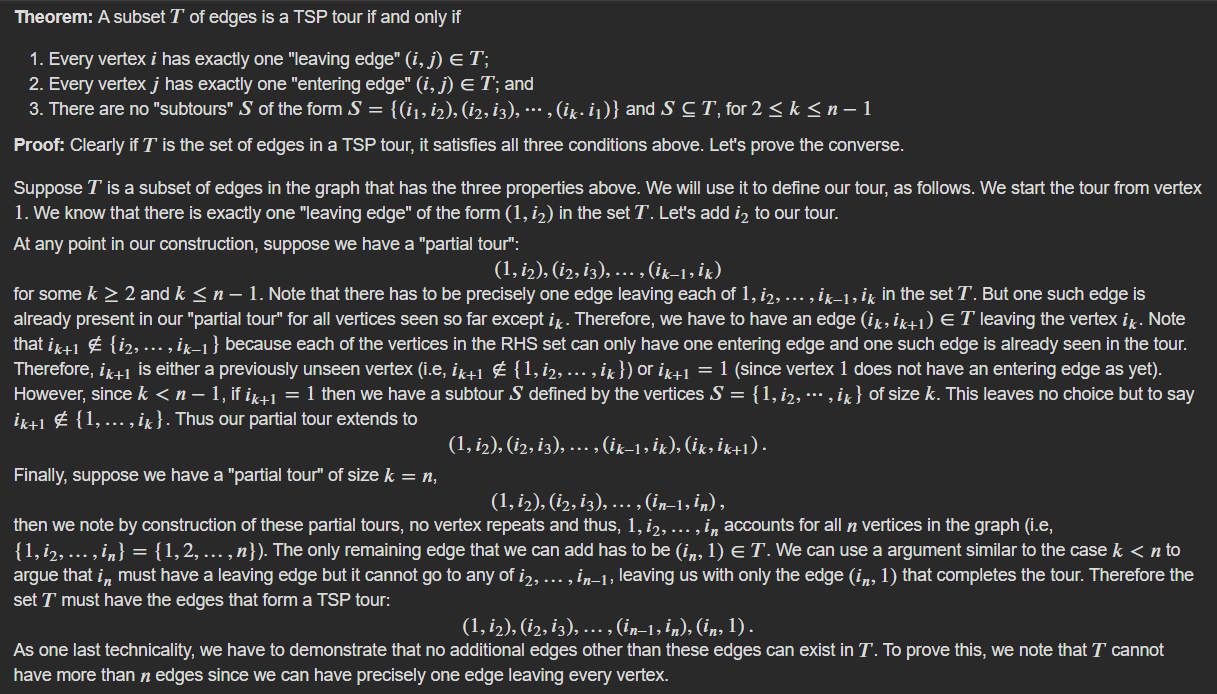

We need to add additional constraints to the two "degree constraints" above so that we can eliminate subtours. There are two ways of doing this: (a) the Miller-Tucker-Zemlin or MTZ approach and (b) incremental subtour elimination.

<h3>MTZ-Approach to Eliminating Subtours</h3>

The first subtour elimination approach is called the MTZ-encoding after the three authors who came up with it:
C.E. Miller, A.W. Tucker and R. A. Zemlin, Integer Programming Formulation of Traveling Salesman Problems, Journal of the ACM, 7(4), 326-329, 1960.

It relies on adding additional decision variables in addition to the  𝑥𝑖,𝑗
  variables that we have already seen.

We associate time-stamp decision variables  𝑡2,…,𝑡𝑛, wherein  𝑡𝑖 denotes a notion of time at which vertex  𝑖 is visited. For technical reasons, no time stamps are given to vertex  1 since it is visited "twice" once as our nominal start of the tour and another time as the "end" of the tour.
Ideally, we will have the  𝑡𝑖 variables be integers but that is not strictly needed for our formulation. We can let them be real-valued decision variables and that makes the solving easier, as explained below.

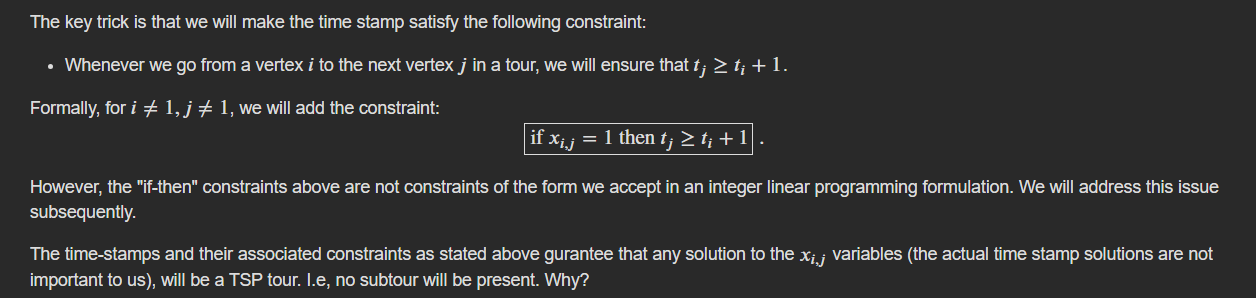

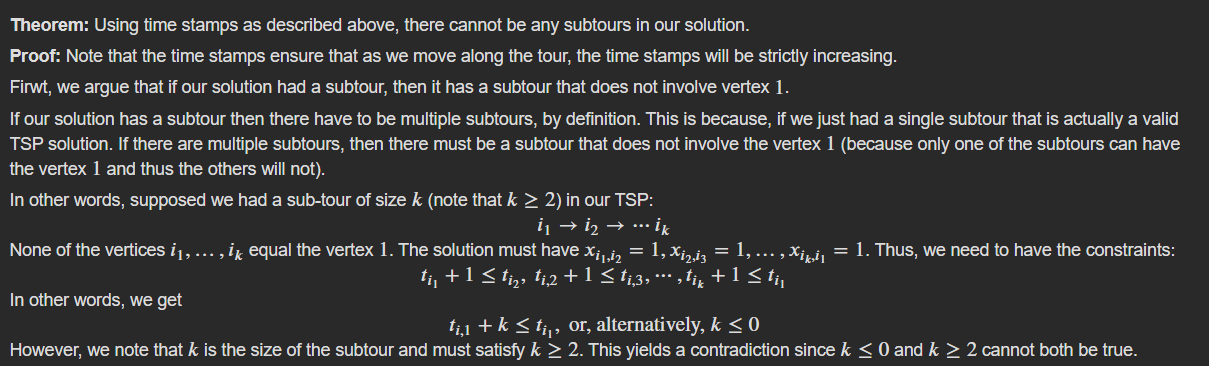


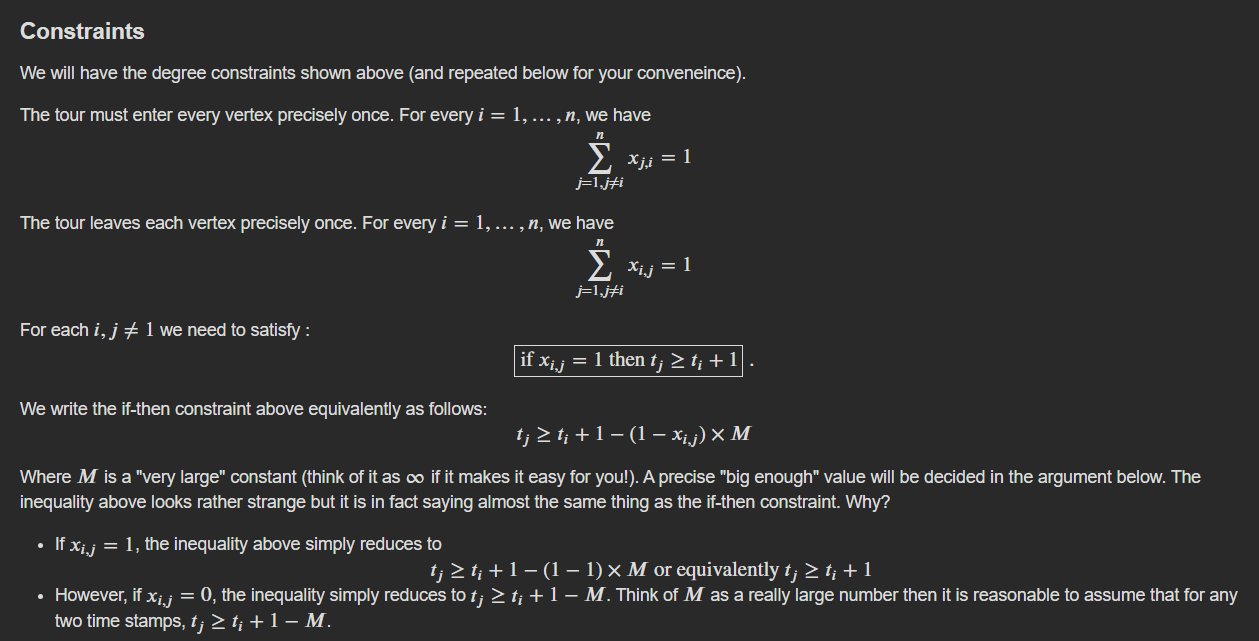

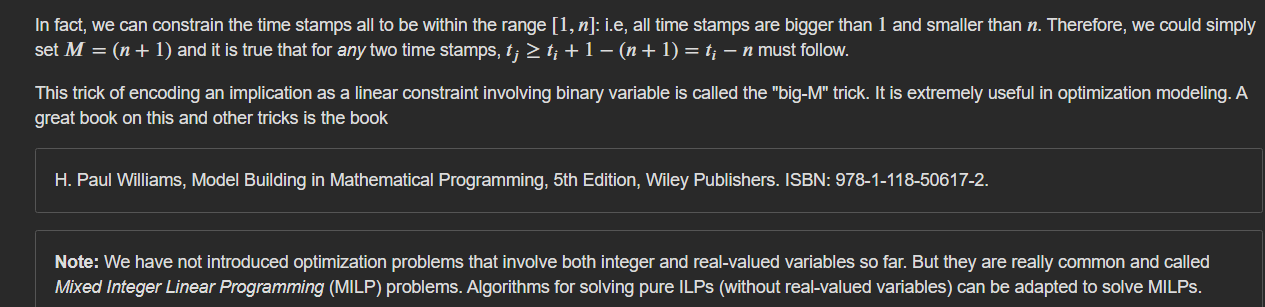


In [9]:
from pulp import *

def mtz_encoding_tsp(n, cost_matrix):
    assert len(cost_matrix) == n, f'Cost matrix is not {n}x{n}'
    assert all(len(cj) == n for cj in cost_matrix), f'Cost matrix is not {n}x{n}'
    # create our encoding variables
    binary_vars = [ # add a binary variable x_{ij} if i not = j else simply add None
        [ LpVariable(f'x_{i}_{j}', cat='Binary') if i != j else None for j in range(n)] 
        for i in range(n) ]
    # add time stamps for ranges 1 .. n (skip vertex 0 for timestamps)
    time_stamps = [LpVariable(f't_{j}', lowBound=0, upBound=n, cat='Continuous') for j in range(1, n)]
    # create the problem
    prob = LpProblem('TSP-MTZ', LpMinimize)
    # create add the objective function 
    objective_function = lpSum( [ lpSum([xij*cj if xij != None else 0 for (xij, cj) in zip(brow, crow) ])
                           for (brow, crow) in zip(binary_vars, cost_matrix)] )
    
    prob += objective_function 
    
    # add the degree constraints
    for i in range(n):
        # Exactly one leaving variable
        prob += lpSum([xj for xj in binary_vars[i] if xj != None]) == 1
        # Exactly one entering
        prob += lpSum([binary_vars[j][i] for j in range(n) if j != i]) == 1
    # add time stamp constraints
    for i in range(1,n):
        for j in range(1, n):
            if i == j: 
                continue
            xij = binary_vars[i][j]
            ti = time_stamps[i-1]
            tj = time_stamps[j -1]
            prob += tj >= ti + xij - (1-xij)*(n+1) # add the constraint
    # Done: solve the problem
    status = prob.solve(PULP_CBC_CMD(msg=False)) # turn off messages
    assert status == constants.LpStatusOptimal, f'Unexpected non-optimal status {status}'
    # Extract the tour
    tour = [0]
    tour_cost = 0
    while len(tour) < n:
        i = tour[-1]
        # find all indices j such that x_ij >= 0.999 
        sols = [j for (j, xij) in enumerate(binary_vars[i]) if xij != None and xij.varValue >= 0.999]
        assert len(sols) == 1, f'{sols}' # there better be just one such vertex or something has gone quite wrong
        j = sols[0] # extract the lone solutio 
        tour_cost = tour_cost + cost_matrix[i][j] # add to the tour cost
        tour.append(j) # append to the tour
        assert j != 0
    i = tour[-1]
    tour_cost = tour_cost + cost_matrix[i][0]
    return tour, tour_cost
        

time: 750 ms (started: 2024-11-13 19:06:03 -08:00)


We will run the code on the same examples as before and note that the overall cost remains the same.

In [10]:
cost_matrix = [ [ 0, 1, 3, 4],
                [ 1, 0, 2, 3 ], 
                [ 3, 2, 0, 4 ], 
                [ 4, 3, 4, 0]]

mtz_encoding_tsp(4, cost_matrix)

([0, 1, 2, 3], 11)

time: 453 ms (started: 2024-11-13 19:06:03 -08:00)


In [11]:
cost_matrix = [ [ 0, 1, 3, 4, 2 ],
                [ 1, 0, 2, 3, 1 ], 
                [ 3, 2, 0, 4 , 3], 
                [ 4, 3, 4, 0, 4 ],
                [ 2, 1, 3, 4, 0 ]]

mtz_encoding_tsp(5, cost_matrix)

([0, 2, 3, 4, 1], 13)

time: 63 ms (started: 2024-11-13 19:06:04 -08:00)


In [12]:
cost_matrix = [
    [ 0, 12, 10, 19, 8],
    [ 12, 0, 3, 7, 19],
    [ 10, 3, 0, 6, 20],
    [ 19, 7, 6, 0, 4],
    [ 8, 19, 20, 4, 0]
]
mtz_encoding_tsp(5,cost_matrix)

([0, 2, 1, 3, 4], 32)

time: 78 ms (started: 2024-11-13 19:06:04 -08:00)


In [13]:
cost_matrix = [
    [0, 12, 29, 22, 13, 24],
    [12, 0, 19, 3, 25, 6],
    [29, 19, 0, 21, 23, 28],
    [22, 3, 21, 0, 4, 5],
    [13, 25, 23, 4, 0, 16],
    [24, 6, 28, 5, 16, 0]
]
mtz_encoding_tsp(6, cost_matrix)

([0, 4, 3, 5, 1, 2], 76)

time: 94 ms (started: 2024-11-13 19:06:04 -08:00)


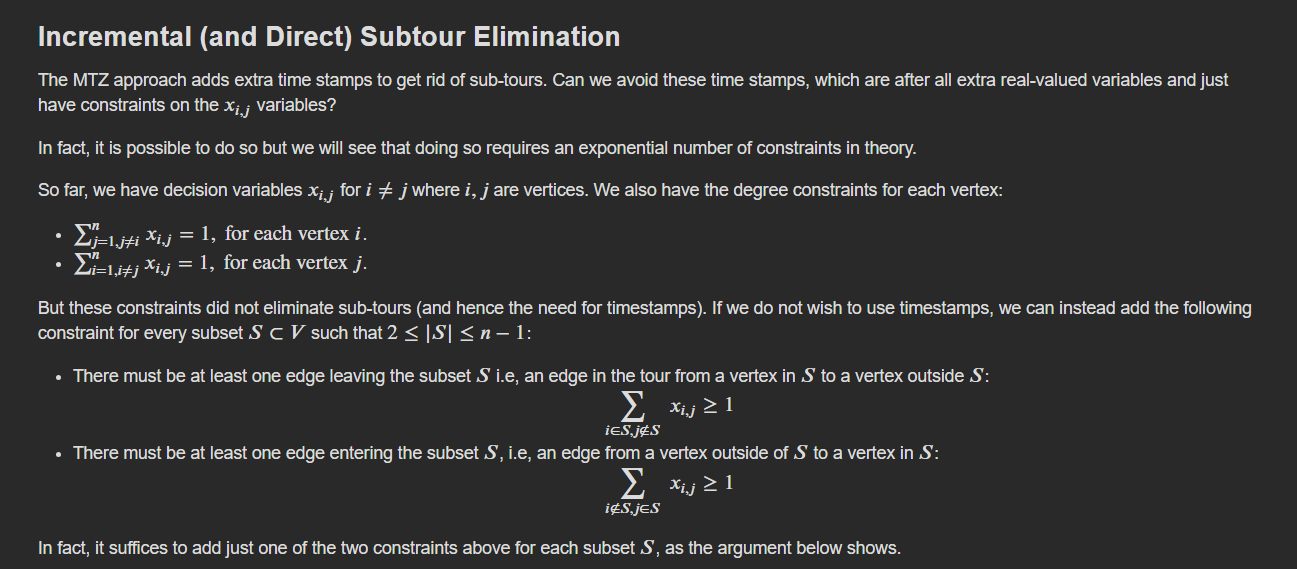

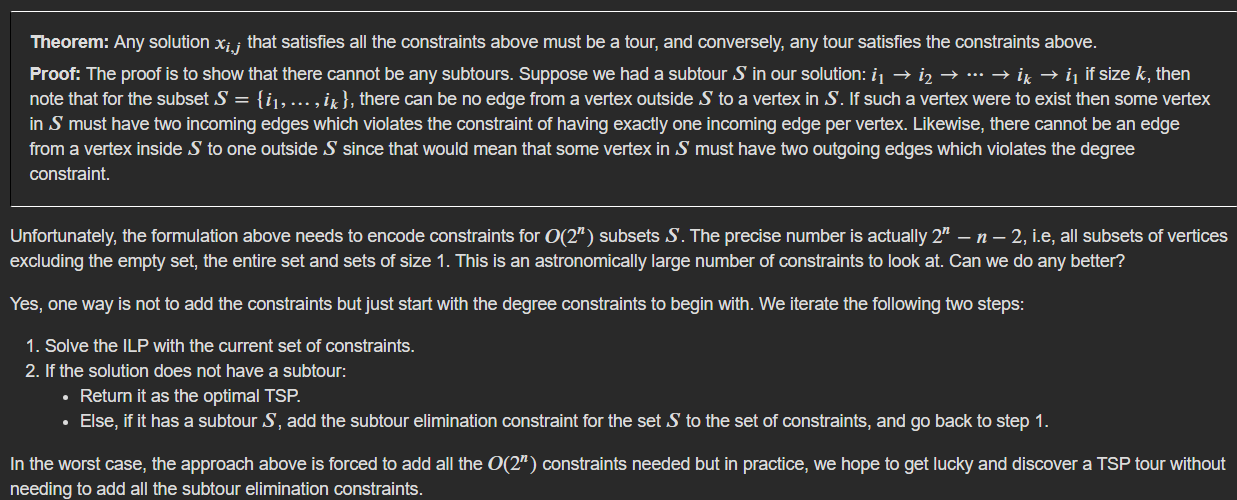

In [14]:
from pulp import * 


def encode_with_subtour_elimination(n, cost_matrix, debug=True):
    assert len(cost_matrix) == n, f'Cost matrix is not {n}x{n}'
    assert all(len(cj) == n for cj in cost_matrix), f'Cost matrix is not {n}x{n}'
    # create our encoding variables
    binary_vars = [ # add a binary variable x_{ij} if i not = j else simply add None
        [ LpVariable(f'x_{i}_{j}', cat='Binary') if i != j else None for j in range(n)] 
        for i in range(n) ]
    # create the problem
    prob = LpProblem('TSP-MTZ', LpMinimize)
    # create add the objective function 
    objective_function = lpSum( [ lpSum([xij*cj if xij != None else 0 for (xij, cj) in zip(brow, crow) ])
                           for (brow, crow) in zip(binary_vars, cost_matrix)] )
    prob += objective_function 
    # add the degree constraints
    for i in range(n):
        # Exactly one leaving variable
        prob += lpSum([xj for xj in binary_vars[i] if xj != None]) == 1
        # Exactly one entering
        prob += lpSum([binary_vars[j][i] for j in range(n) if j != i]) == 1
    done = False
    while not done:
        # solve the problem as it is now
        status = prob.solve(PULP_CBC_CMD(msg=False)) # turn off messages
        assert status == constants.LpStatusOptimal, 'Unknown error : status should be optimal'
        (has_subtour, tour) = check_solution(n, binary_vars) # returns if the problem has a subtour and the tour
        if has_subtour: 
            # write down the constraint to block the subtour moving forward
            if debug:
                print(f'\t Found subtour: {tour}. Adding constraint to eliminate.')
            prob += ( lpSum([ lpSum([binary_vars[i][j] for j in range(n) if j not in tour]) for i in tour ])) >= 1
        else: 
            tour_cost = objective_function.value()
            if debug:
                print(f'Success: Found tour {tour} of cost {tour_cost}')
            done = True
    return (tour, tour_cost)


def check_solution(n, binary_vars):
    # search to see if there is a subtour.
    # 1. start from vertex 0
    # 2. find the outgoing vertex and keep going until we circle back.
    # This is going to be nearly identical to the solution extraction procedure we had in our earlier encoding.
    tour = [0]
    done = False
    while not done:
        i = tour[-1]
        sols = [j for (j, xij) in enumerate(binary_vars[i]) if xij != None and xij.varValue >= 0.999]
        #assert 0.99999 <= sum(sols) <= 1.00001, f'# of outgoing vertices for {i} is {sum(sols)}, solution: {sols}'
        assert len(sols) == 1, f'{sols}'
        j = sols[0]
        if j != 0:
            tour.append(j)
        else:
            done = True
        if len(tour)== n:
            done = True
    has_sub_tour = (len(tour) < n)
    return has_sub_tour, tour


time: 0 ns (started: 2024-11-13 19:06:04 -08:00)


In [15]:
cost_matrix = [ [ 0, 1, 3, 4],
                [ 1, 0, 2, 3 ], 
                [ 3, 2, 0, 4 ], 
                [ 4, 3, 4, 0]]

encode_with_subtour_elimination(4, cost_matrix)

	 Found subtour: [0, 1]. Adding constraint to eliminate.
Success: Found tour [0, 2, 3, 1] of cost 11.0


([0, 2, 3, 1], 11.0)

time: 125 ms (started: 2024-11-13 19:06:04 -08:00)


In [16]:
cost_matrix = [ [ 0, 1, 3, 4, 2 ],
                [ 1, 0, 2, 3, 1 ], 
                [ 3, 2, 0, 4 , 3], 
                [ 4, 3, 4, 0, 4 ],
                [ 2, 1, 3, 4, 0 ]]

encode_with_subtour_elimination(5, cost_matrix)

	 Found subtour: [0, 1, 4]. Adding constraint to eliminate.
Success: Found tour [0, 2, 3, 1, 4] of cost 13.0


([0, 2, 3, 1, 4], 13.0)

time: 109 ms (started: 2024-11-13 19:06:04 -08:00)


In [17]:
cost_matrix = [
    [ 0, 12, 10, 19, 8],
    [ 12, 0, 3, 7, 19],
    [ 10, 3, 0, 6, 20],
    [ 19, 7, 6, 0, 4],
    [ 8, 19, 20, 4, 0]
]
encode_with_subtour_elimination(5,cost_matrix)

	 Found subtour: [0, 4]. Adding constraint to eliminate.
Success: Found tour [0, 4, 3, 1, 2] of cost 32.0


([0, 4, 3, 1, 2], 32.0)

time: 94 ms (started: 2024-11-13 19:06:04 -08:00)


In [18]:
cost_matrix = [
    [0, 12, 29, 22, 13, 24],
    [12, 0, 19, 3, 25, 6],
    [29, 19, 0, 21, 23, 28],
    [22, 3, 21, 0, 4, 5],
    [13, 25, 23, 4, 0, 16],
    [24, 6, 28, 5, 16, 0]
]
encode_with_subtour_elimination(6, cost_matrix)

	 Found subtour: [0, 4]. Adding constraint to eliminate.
Success: Found tour [0, 4, 3, 5, 1, 2] of cost 76.0


([0, 4, 3, 5, 1, 2], 76.0)

time: 110 ms (started: 2024-11-13 19:06:04 -08:00)


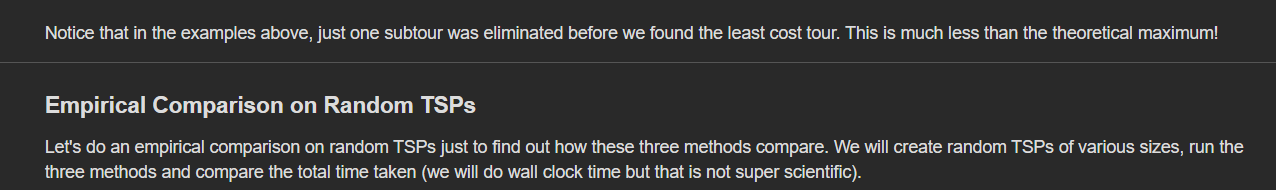

In [19]:
from random import uniform
from timeit import default_timer as timer

def mk_cost_matrix(n, min_cost=0, max_cost=100):
    assert n >= 2
    return [ [ uniform(min_cost, max_cost) if i != j else None for j in range(n)] for i in range(n)]


def run_comparisons(n, num_compare=100, debug=False):
    total_held_karp = 0
    total_mtz = 0
    total_subt_elim = 0
    for i in range(num_compare):
        cost_matrix = mk_cost_matrix(n)
        # Held-Karp
        t1 = timer()
        (_, cost1) = memoize_min_cost_path(n, cost_matrix, False)
        t2 = timer()
        # MTZ
        (_, cost2) = mtz_encoding_tsp(n, cost_matrix)
        t3 = timer()
        (_, cost3) = encode_with_subtour_elimination(n, cost_matrix, debug=False)
        t4 = timer()
        assert abs(cost1 - cost2) <= 1E-03, 'Held Karp and MTZ costs disagree : {cost1} vs {cost2}'
        assert abs(cost2-cost3) <= 1E-03, 'MTZ and Subtour elimination costs disagree {cost2} vs {cost3}'
        if debug:
            print(f'Trial: {i}. Held-Karp cost: {cost1}, MTZ cost: {cost2}, Subtour elim cost: {cost3}')
            print(f'\t Held-Karp time: %.2f seconds, MTZ cost: %.2f seconds, Subtour elim cost: %.2f seconds' %(t2-t1, t3-t2, t4-t3))
        total_held_karp += (t2 - t1)
        total_mtz += (t3 - t2)
        total_subt_elim += (t4-t3)
        
    return (total_held_karp/num_compare, total_mtz/num_compare, total_subt_elim/num_compare)
    
run_comparisons(10, 10, True)

Trial: 0. Held-Karp cost: 124.57276459816677, MTZ cost: 124.57276459816677, Subtour elim cost: 124.57276459816677
	 Held-Karp time: 0.02 seconds, MTZ cost: 0.12 seconds, Subtour elim cost: 0.10 seconds
Trial: 1. Held-Karp cost: 189.69035987232687, MTZ cost: 189.69035987232687, Subtour elim cost: 189.69035987232687
	 Held-Karp time: 0.02 seconds, MTZ cost: 0.19 seconds, Subtour elim cost: 0.32 seconds
Trial: 2. Held-Karp cost: 179.98875550679634, MTZ cost: 179.98875550679634, Subtour elim cost: 179.98875550679637
	 Held-Karp time: 0.01 seconds, MTZ cost: 0.31 seconds, Subtour elim cost: 0.36 seconds
Trial: 3. Held-Karp cost: 200.17425637742792, MTZ cost: 200.17425637742792, Subtour elim cost: 200.1742563774279
	 Held-Karp time: 0.01 seconds, MTZ cost: 0.13 seconds, Subtour elim cost: 0.10 seconds
Trial: 4. Held-Karp cost: 162.79649981895915, MTZ cost: 162.79649981895915, Subtour elim cost: 162.79649981895918
	 Held-Karp time: 0.02 seconds, MTZ cost: 0.25 seconds, Subtour elim cost: 0.41

(0.014767250003933441, 0.1759880899990094, 0.25906070999917574)

time: 4.52 s (started: 2024-11-13 19:06:05 -08:00)


In [20]:
from matplotlib import pyplot as plt 
## Warning this will take about 30 minutes to run to run: go grab a coffee!
average_hk = []
average_mtz = []
average_st_elim = []
for n in range(4, 19):
    print(f'Running n ={n}')
    (a1, a2, a3) = run_comparisons(n, 50)
    average_hk.append(a1)
    average_mtz.append(a2)
    average_st_elim.append(a3)

Running n =4
Running n =5
Running n =6
Running n =7
Running n =8
Running n =9
Running n =10
Running n =11
Running n =12
Running n =13
Running n =14
Running n =15
Running n =16
Running n =17
Running n =18
time: 19min 10s (started: 2024-11-13 19:06:09 -08:00)


In [21]:
# This is the data from the previous cell that we have saved on our machine locall
print(average_hk)
print(average_mtz)
print(average_st_elim)

[8.584399911342189e-05, 0.00017742800060659646, 0.00032096799957798795, 0.001024565999978222, 0.002786508000572212, 0.006656663999892771, 0.017217960001144093, 0.027885534000815823, 0.06449834599887254, 0.13244396599999164, 0.2886060020001605, 0.6560631019982975, 1.5459151300005032, 3.452462682000478, 7.910619239999214]
[0.08506982200022321, 0.10167180599906715, 0.10066518799983896, 0.13543494999903488, 0.14999667399912142, 0.1700972559998627, 0.17589016600017204, 0.17307153600035236, 0.22256150799919852, 0.2632306480020634, 0.29959131000039635, 0.3602886419999413, 0.3600351319997571, 0.46244806999980936, 0.6688356920002844]
[0.10421222200064222, 0.14233547199954047, 0.12793160600034753, 0.1858446060004644, 0.21148188199993456, 0.26228942999994614, 0.2697624679995351, 0.233046623999835, 0.2557720480009448, 0.41779159199795685, 0.44065181799960557, 0.5332833999994909, 0.5180531539997901, 0.6001406059996225, 0.7200072180002463]
time: 0 ns (started: 2024-11-13 19:25:19 -08:00)


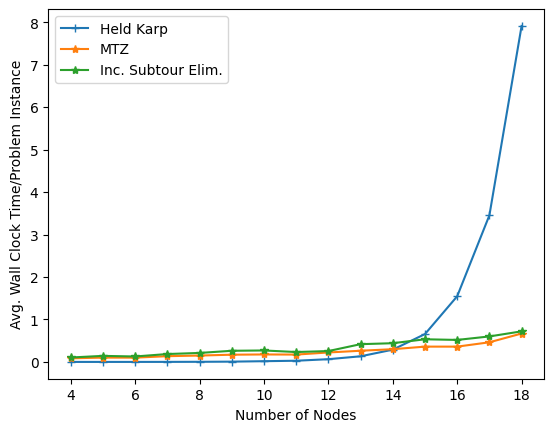

time: 672 ms (started: 2024-11-13 19:25:19 -08:00)


In [22]:
plt.plot(range(4, 19), average_hk, '-+', label='Held Karp')
plt.plot(range(4, 19), average_mtz, '-*', label='MTZ')
plt.plot(range(4, 19), average_st_elim, '-*', label='Inc. Subtour Elim.')
plt.legend()
plt.xlabel('Number of Nodes')
plt.ylabel('Avg. Wall Clock Time/Problem Instance')
plt.show()

Surprisingly, the <u> algorithm that performs best in practice is the one that should theoretically have the worst time complexity </u> : the integer linear programming approach based on sub-tour elimination. Note that there are many issues with our comparison: we are not using a particularly efficient ILP solver. <u> Commercial solvers such as Gurobi </u> will be much faster than the open source solver we are using. Also, our implementation of the Held-Karp algorithm can benefit from many improvements such as better data stucture for the memo table.

However, solving TSPs exactly is now possible for <u> very large instances </u> . For instance, the <a href="https://www.math.uwaterloo.ca/tsp/concorde.html" > Concorde TSP solver </a> can solve TSP instances with as many as <u>  85900 vertices </u> arising from a circuit design application.